# 销售订单数据分析

## 数据清洗

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df=pd.read_csv('某电子产品公司销售订单数据集.csv')
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


### 修改列名

In [4]:
colnames={
    'Order Date':'订单日期',
    'Product Name':'产品名称',
    'Category':'类别',
    'Region':'地区',
    'Quantity':'数量',
    'Sales':'销售额',
    'Profit':'利润'
}
df=df.rename(columns=colnames)
df.head()

,订单日期,产品名称,类别,地区,数量,销售额,利润
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [5]:
df['订单日期']=pd.to_datetime(df['订单日期'])
df.info()
# df.columns.tolist()
# df.columns.duplicated()
# df.info()
# df = df.loc[:, ~df.columns.duplicated()]   #~取反
# df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单日期    3500 non-null   datetime64[ns]
 1   产品名称    3500 non-null   object        
 2   类别      3500 non-null   object        
 3   地区      3500 non-null   object        
 4   数量      3500 non-null   int64         
 5   销售额     3500 non-null   int64         
 6   利润      3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


### 缺失值

In [6]:
df.isnull().sum()/len(df)  #无缺失值
# df.notnull().sum()/len(df)
# df.isnull().mean()

订单日期    0.0
产品名称    0.0
类别      0.0
地区      0.0
数量      0.0
销售额     0.0
利润      0.0
dtype: float64

### 重复值

In [7]:
# df[df.duplicated()]  #无重复行
df.drop_duplicates().nunique()

订单日期    1051
产品名称      10
类别         3
地区         4
数量         9
销售额     2377
利润      3447
dtype: int64

In [8]:
df

,订单日期,产品名称,类别,地区,数量,销售额,利润
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


## 数据分析

### 整体绩效概况
- 计算总销售额、总利润、整体利润率；统计总订单数、总销量

In [9]:
# 计算核心指标
total_sales=df['销售额'].sum()
total_profit=df['利润'].sum()
total_quantity=df['数量'].sum()

avg_margin=(total_profit/total_sales)*100  #平均利润
print('平均利润:',avg_margin)
profit_orders=df[df['利润']>0].count()
loss_orders=df[df['利润']<0].count()
print('盈利订单数量:',profit_orders)
print('亏损订单数量:',loss_orders)

平均利润: 17.29176778406133
盈利订单数量: 订单日期    3500
产品名称    3500
类别      3500
地区      3500
数量      3500
销售额     3500
利润      3500
dtype: int64
亏损订单数量: 订单日期    0
产品名称    0
类别      0
地区      0
数量      0
销售额     0
利润      0
dtype: int64


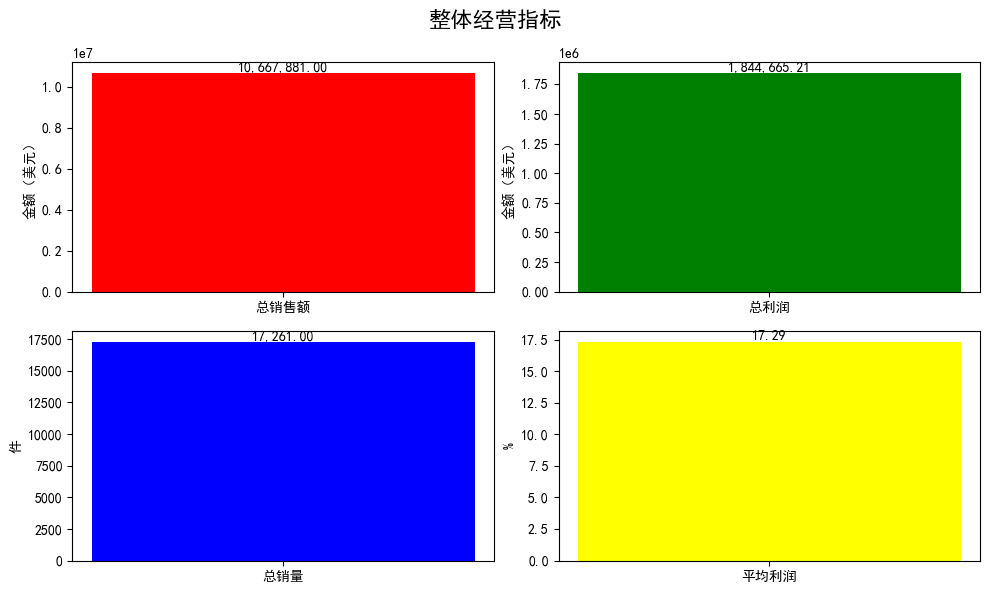

In [10]:
# 核心指标图
fig,axes=plt.subplots(2,2,figsize=(10,6))
fig.suptitle('整体经营指标',fontsize=16)

metrics=[total_sales,total_profit,total_quantity,avg_margin]
title=['总销售额','总利润','总销量','平均利润']
colors=['red','green','blue','yellow']
for i,ax in enumerate(axes.flat):
    ax.bar(title[i],metrics[i],color=colors[i],width=0.5)
    # ax.set_title(title[i])
    ax.set_ylabel('金额（美元）' if i<2 else ('件' if i==2 else '%'))
    ax.text(0,metrics[i],f'{metrics[i]:,.2f}',ha='center',va='bottom')

plt.tight_layout()
plt.show()

In [1]:
### axes语法
'''
基本图形
ax.plot(x, y)                    # 折线图
ax.scatter(x, y)                 # 散点图
ax.bar(x, height)                # 柱状图
ax.barh(y, width)                # 水平柱状图
ax.hist(data, bins=30)           # 直方图
ax.pie(data, labels=labels)      # 饼图
ax.boxplot(data)                 # 箱线图


标题
ax.set_title('标题', fontsize=14, fontweight='bold', color='red')
ax.set_title('标题', loc='left')   # 左对齐
ax.set_title('标题', loc='right')  # 右对齐

轴标签
ax.set_xlabel('X轴标签', fontsize=12)
ax.set_ylabel('Y轴标签', fontsize=12)

坐标轴范围
ax.set_xlim(0, 10)               # X轴范围
ax.set_ylim(-5, 5)               # Y轴范围
ax.set_xlim(left=0, right=10)    # 单独设置
ax.set_ylim(bottom=-5, top=5)

坐标轴刻度
ax.set_xticks([0, 2, 4, 6, 8, 10])           # 设置刻度位置
ax.set_xticklabels(['A', 'B', 'C', 'D', 'E', 'F'])  # 设置刻度标签
ax.tick_params(axis='x', rotation=45)        # 旋转刻度标签

对数刻度
ax.set_xscale('log')              # 对数坐标
ax.set_yscale('log')
ax.set_xscale('log', base=2)      # 以2为底

网格线
ax.grid(True)                     # 显示网格
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(axis='x')                 # 只显示x轴网格
ax.grid(axis='y')                 # 只显示y轴网格

图例
ax.legend()                       # 自动添加图例
ax.legend(['数据1', '数据2'])      # 手动指定
ax.legend(loc='upper right')      # 位置
ax.legend(bbox_to_anchor=(1.05, 1))  # 放到图外

颜色条
sc = ax.scatter(x, y, c=z)
plt.colorbar(sc, ax=ax)           # 添加颜色条

背景色
ax.set_facecolor('#F5F5F5')       # 设置背景色
ax.patch.set_alpha(0.5)           # 设置透明度
'''

"\n基本图形\nax.plot(x, y)                    # 折线图\nax.scatter(x, y)                 # 散点图\nax.bar(x, height)                # 柱状图\nax.barh(y, width)                # 水平柱状图\nax.hist(data, bins=30)           # 直方图\nax.pie(data, labels=labels)      # 饼图\nax.boxplot(data)                 # 箱线图\n\n\n标题\nax.set_title('标题', fontsize=14, fontweight='bold', color='red')\nax.set_title('标题', loc='left')   # 左对齐\nax.set_title('标题', loc='right')  # 右对齐\n\n轴标签\nax.set_xlabel('X轴标签', fontsize=12)\nax.set_ylabel('Y轴标签', fontsize=12)\n\n坐标轴范围\nax.set_xlim(0, 10)               # X轴范围\nax.set_ylim(-5, 5)               # Y轴范围\nax.set_xlim(left=0, right=10)    # 单独设置\nax.set_ylim(bottom=-5, top=5)\n\n坐标轴刻度\nax.set_xticks([0, 2, 4, 6, 8, 10])           # 设置刻度位置\nax.set_xticklabels(['A', 'B', 'C', 'D', 'E', 'F'])  # 设置刻度标签\nax.tick_params(axis='x', rotation=45)        # 旋转刻度标签\n\n对数刻度\nax.set_xscale('log')              # 对数坐标\nax.set_yscale('log')\nax.set_xscale('log', base=2)      # 以2为底\n\n网格线\nax.grid(True)

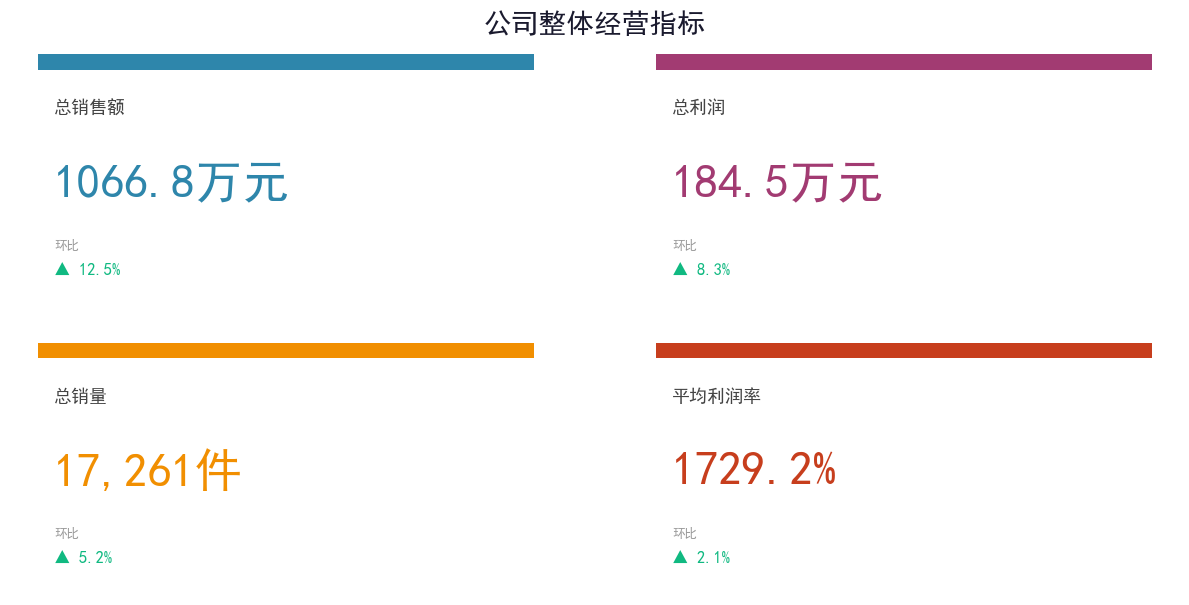

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
fig.suptitle('公司整体经营指标', fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')

metrics = [total_sales, total_profit, total_quantity, avg_margin]
titles = ['总销售额', '总利润', '总销量', '平均利润率']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
# colors = ['red', 'green', 'blue', 'yellow']
mom_changes = [12.5, 8.3, 5.2, 2.1]


for i, ax in enumerate(axes.flat):
    ax.axis('off')
    ax.set_facecolor('#FFFFFF')

    # 顶部色条
    top_bar = plt.Rectangle((0.05, 0.92), 0.9, 0.06,
                            transform=ax.transAxes,
                            facecolor=colors[i],
                            clip_on=False)
    ax.add_patch(top_bar)

    # 边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#EEEEEE')
        spine.set_linewidth(2)

    # 标题
    ax.text(0.08, 0.75, titles[i],
            transform=ax.transAxes, fontsize=13, color='#444444',
            fontweight='600', ha='left')

    # 数值
    if i == 3:
        value = metrics[i] * 100
        value_str = f'{value:.1f}%'
    else:
        value = metrics[i]
        if i < 2 and value >= 10000:
            value_str = f'{value/10000:.1f}万元'
        elif i < 2:
            value_str = f'{value:,.0f}元'
        else:
            value_str = f'{value:,.0f}件'

    ax.text(0.08, 0.48, value_str,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=34, color=colors[i], fontweight='bold')

    # 环比
    mom_color = '#10b981' if mom_changes[i] >= 0 else '#ef4444'
    mom_icon = '▲' if mom_changes[i] >= 0 else '▼'
    mom_text = f'{mom_icon} {abs(mom_changes[i]):.1f}%'

    ax.text(0.08, 0.22, '环比',
            transform=ax.transAxes, fontsize=9, color='#999999')
    ax.text(0.08, 0.12, mom_text,
            transform=ax.transAxes, fontsize=12, color=mom_color, fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08,
                    hspace=0.12, wspace=0.12)
plt.show()

### 产品销售排行

In [14]:
# 按产品汇总
product_stats=df.groupby(by='产品名称').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()

# 利润率
product_stats['margin']=(product_stats['利润']/profit_orders['销售额'])*100

# top 10 销售额
top10_sales=product_stats.nlargest(10,'销售额')
bottom10_sales=product_stats.nsmallest(10,'销售额')

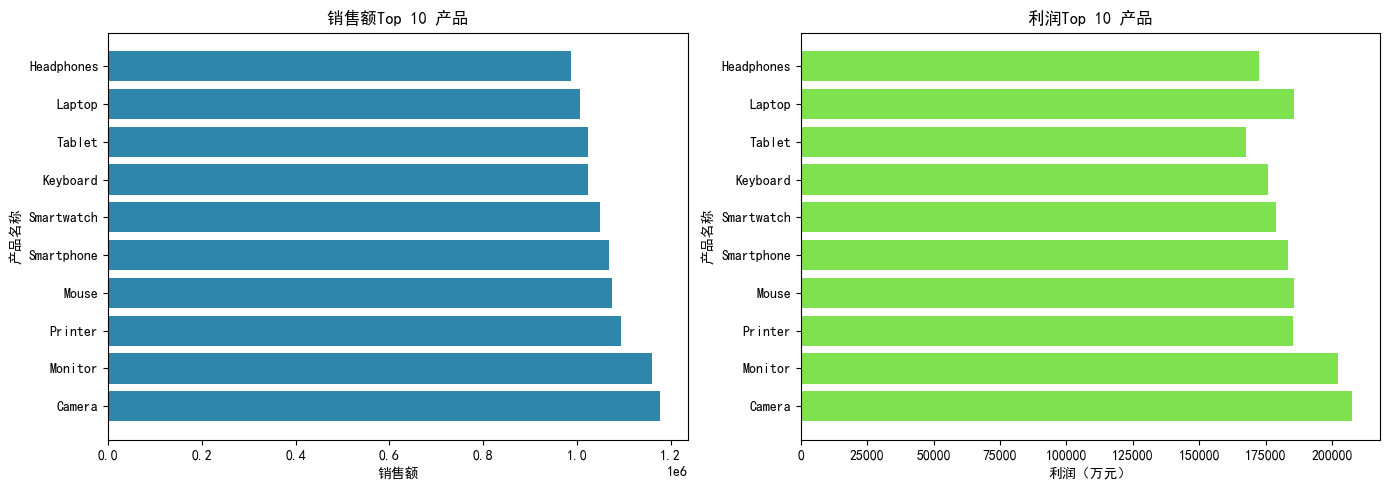

In [15]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
# sns.barplot(data=top10_sales,y='产品名称',x='销售额',ax=axes[0],palette='Blues_r')
# axes[0].set_title('销售额Top 10 产品')
# axes[0].set_xlabel('销售额（万元）')
#
# sns.barplot(data=top10_sales,y='产品名称',x='利润',ax=axes[1],palette='Greens_r')
# axes[1].set_title('利润Top 10 产品')
# axes[1].set_xlabel('利润（万元）')

axes[0].barh(top10_sales['产品名称'], top10_sales['销售额'], color='#2E86AB')
axes[0].set_xlabel('销售额')
axes[0].set_ylabel('产品名称')
axes[0].set_title('销售额Top 10 产品')

axes[1].barh(top10_sales['产品名称'], top10_sales['利润'], color='#7de24d')
axes[1].set_xlabel('利润（万元）')
axes[1].set_ylabel('产品名称')
axes[1].set_title('利润Top 10 产品')

plt.tight_layout()
plt.show()

### 类别表现对比

In [16]:
category_stats=df.groupby(by='类别').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()
category_stats['margin']=(category_stats['利润']/category_stats['销售额'])*100

### 调色板

In [17]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [18]:
palettes=sns.hls_palette(10,l=0.6,s=1)
palettes

[(1.0, np.float64(0.24799999999999994), 0.19999999999999996),
 (1.0, np.float64(0.728), 0.19999999999999996),
 (np.float64(0.7919999999999998), 1.0, 0.19999999999999996),
 (np.float64(0.3119999999999999), 1.0, 0.19999999999999996),
 (0.19999999999999996, 1.0, np.float64(0.5680000000000003)),
 (0.19999999999999996, np.float64(0.9519999999999997), 1.0),
 (0.19999999999999996, np.float64(0.4719999999999993), 1.0),
 (np.float64(0.4080000000000005), 0.19999999999999996, 1.0),
 (np.float64(0.8879999999999999), 0.19999999999999996, 1.0),
 (1.0, 0.19999999999999996, np.float64(0.6319999999999999))]

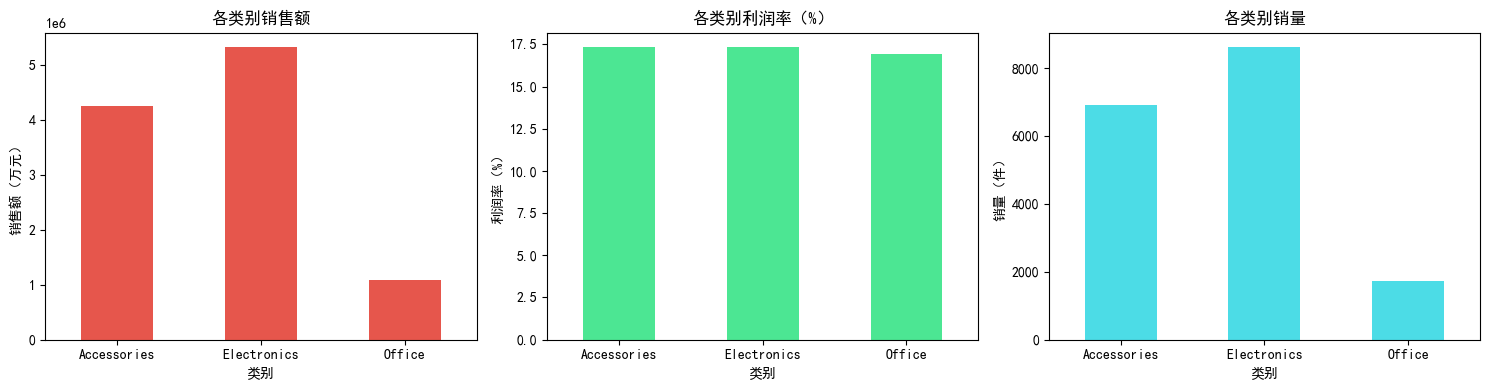

In [19]:
fig,ax=plt.subplots(1,3,figsize=(15,4))

#销售额对比
sns.barplot(data=category_stats,x='类别',y='销售额',ax=ax[0],color=palettes[0],width=0.5)
ax[0].set_title('各类别销售额')
ax[0].set_ylabel('销售额（万元）')

#利润率对比
sns.barplot(data=category_stats,x='类别',y='margin',ax=ax[1],color=palettes[4],width=0.5)
ax[1].set_title('各类别利润率（%）')
ax[1].set_ylabel('利润率（%）')

#销量对比
sns.barplot(data=category_stats,x='类别',y='数量',ax=ax[2],color=palettes[5],width=0.5)
ax[2].set_title('各类别销量')
ax[2].set_ylabel('销量（件）')

plt.tight_layout()
plt.show()

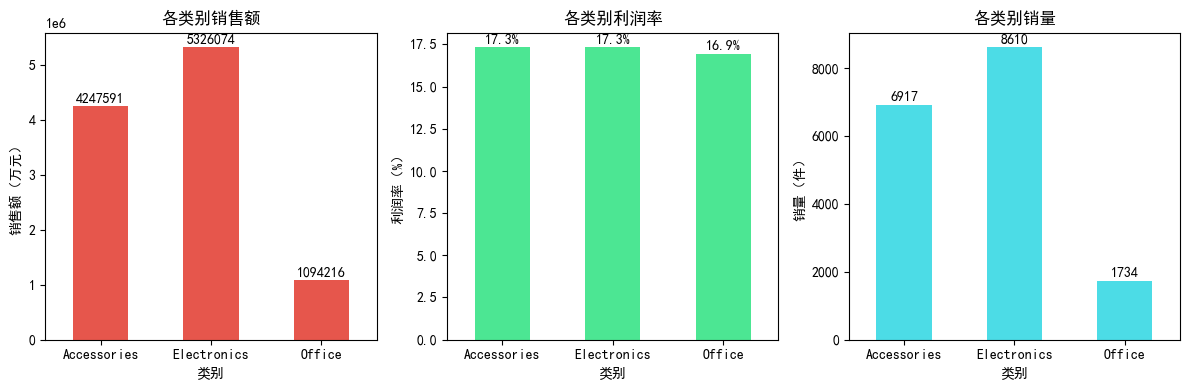

In [20]:
# 优化版
def bar_chart(ax,y_col,color,ylabel,title,data=category_stats,x_col='类别',width=0.5,label_fmt='%.0f',label_padding=1,**label_kwargs):
    # label_padding=5 数值标签与柱子顶端之间的间距（像素），默认为0，贴紧bar
    sns.barplot(data=data,x=x_col,y=y_col,ax=ax,color=color,width=width,**label_kwargs)
    for cont in ax.containers:
        ax.bar_label(cont,fmt=label_fmt,padding=label_padding,**label_kwargs)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
    return ax

# # 数值显示在中间
# def bar_chart(ax,y_col,color,data=category_stats,x_col='类别',width=0.5,label_fmt='%.0f',label_type='center',**label_kwargs):
#     sns.barplot(data=data,x=x_col,y=y_col,ax=ax,color=color,width=width,**label_kwargs)
#     for cont in ax.containers:
#         ax.bar_label(cont,fmt=label_fmt,label_type=label_type,**label_kwargs)
#     return ax
fig,ax=plt.subplots(1,3,figsize=(12,4))
bar_chart(ax[0],y_col='销售额',color=palettes[0],ylabel='销售额（万元）',title='各类别销售额')
bar_chart(ax[1],y_col='margin',color=palettes[4],label_fmt='%.1f%%',ylabel='利润率（%）',title='各类别利润率')
bar_chart(ax[2],y_col='数量',color=palettes[5],ylabel='销量（件）',title='各类别销量')

plt.tight_layout()
plt.show()

### 区域销售分析

In [21]:
region_stats=df.groupby(by='地区').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()
region_stats['margin']=(region_stats['利润']/region_stats['销售额'])*100

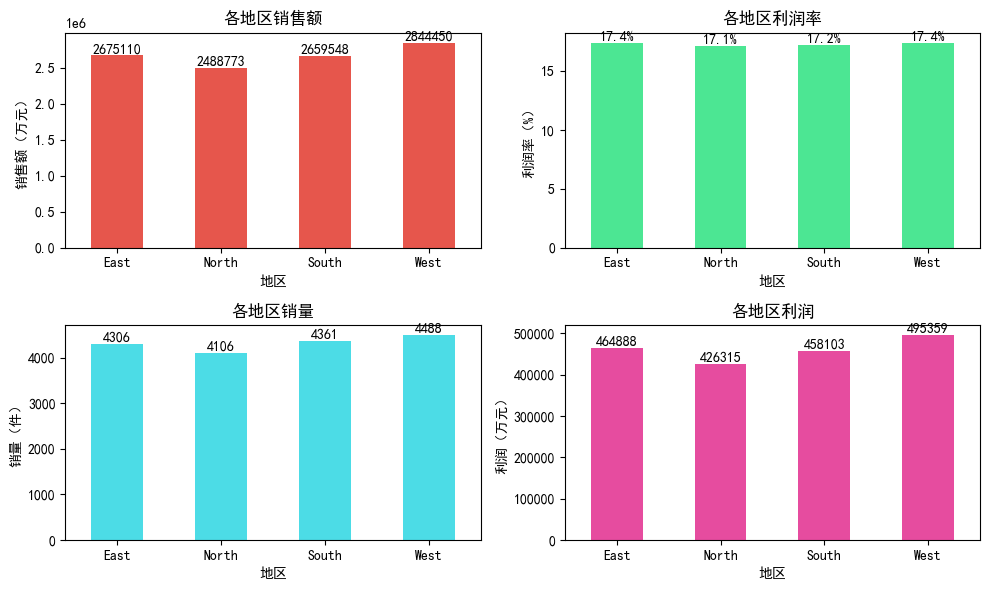

In [22]:
# 优化版
def bar_chart_region(ax,y_col,color,ylabel,title,data=region_stats,x_col='地区',width=0.5,label_fmt='%.0f',label_padding=0,**label_kwargs):
    # label_padding=5 数值标签与柱子顶端之间的间距（像素），默认为0，贴紧bar
    sns.barplot(data=data,x=x_col,y=y_col,ax=ax,color=color,width=width,**label_kwargs)
    for cont in ax.containers:
        ax.bar_label(cont,fmt=label_fmt,padding=label_padding,**label_kwargs)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
    return ax


fig,ax=plt.subplots(2,2,figsize=(10,6))
bar_chart_region(ax[0][0],y_col='销售额',color=palettes[0],ylabel='销售额（万元）',title='各地区销售额')
bar_chart_region(ax[0][1],y_col='margin',color=palettes[4],label_fmt='%.1f%%',ylabel='利润率（%）',title='各地区利润率')
bar_chart_region(ax[1][0],y_col='数量',color=palettes[5],ylabel='销量（件）',title='各地区销量')
bar_chart_region(ax[1][1],y_col='利润',color=palettes[-1],ylabel='利润（万元）',title='各地区利润')

plt.tight_layout()
plt.show()

### 时间趋势分析

In [23]:
df['yearmonthly']=df['订单日期'].dt.strftime('%Y-%m')
df['yearmonthly'].value_counts()
df['yearly']=df['订单日期'].dt.strftime('%Y')
# df.isnull().value_counts()
# df.duplicated().value_counts()
# df
yearmonthly_stats=df.groupby(by='yearmonthly').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()
yearmonthly_stats['margin']=(yearmonthly_stats['利润']/yearmonthly_stats['销售额'])*100

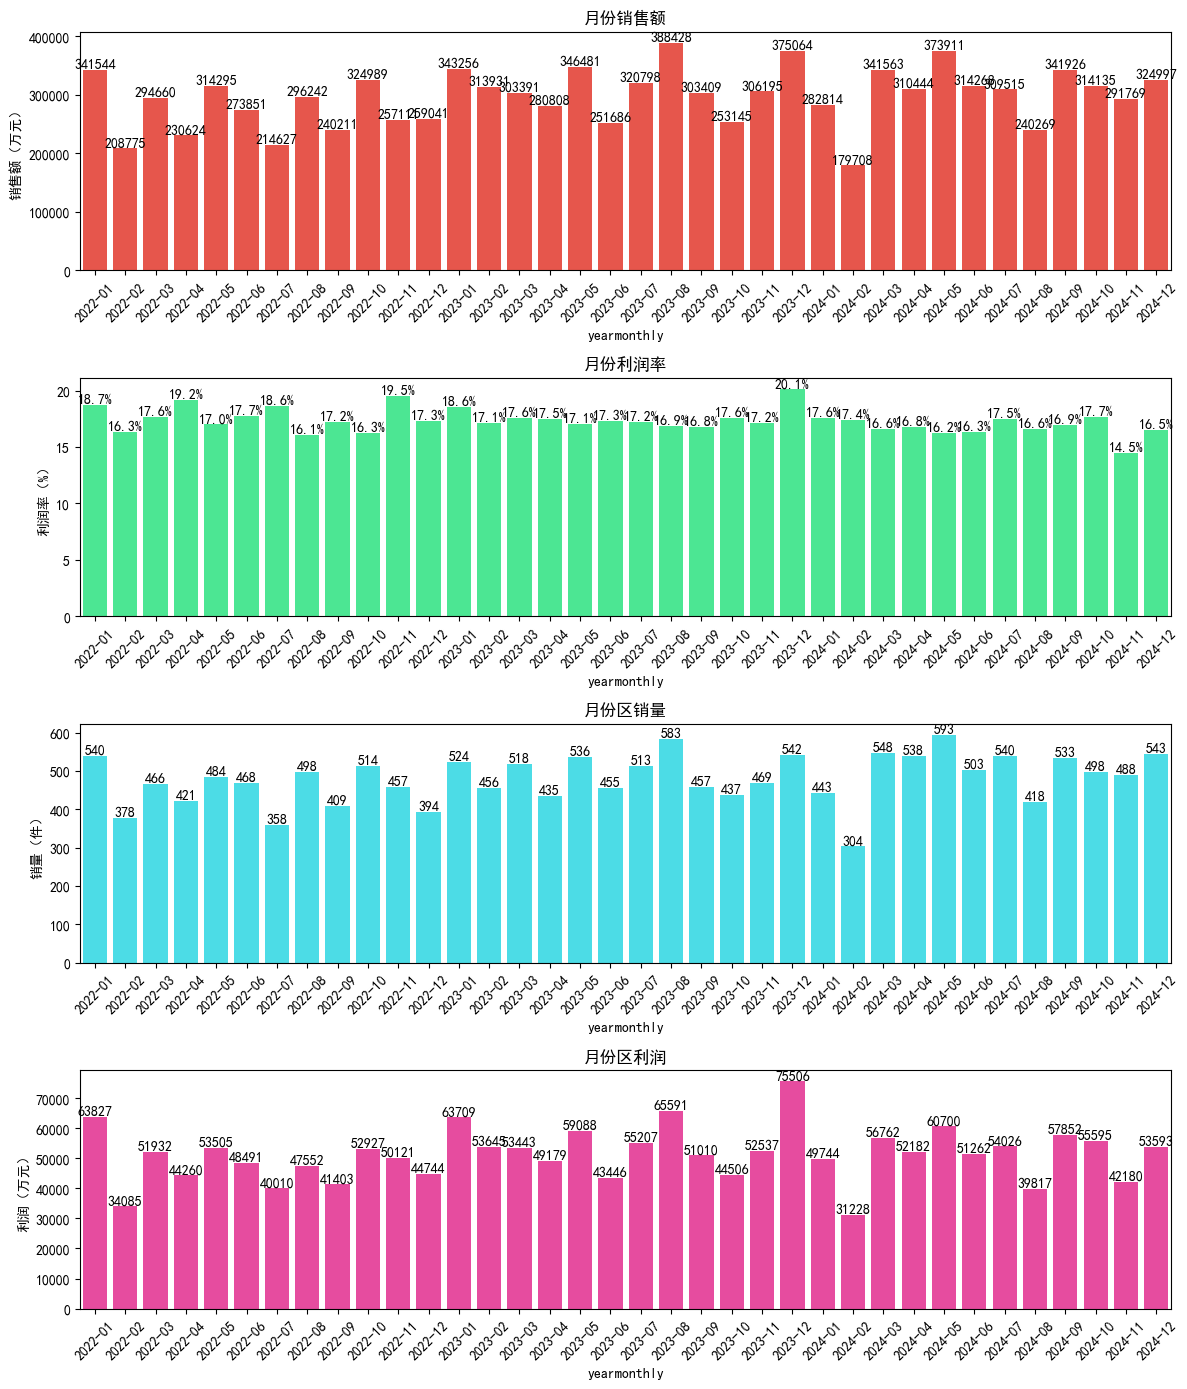

In [24]:
def bar_chart_yearmonthly(ax,y_col,color,ylabel,title,data=yearmonthly_stats,x_col='yearmonthly',label_fmt='%.0f',label_padding=0,x_rotation=45,**label_kwargs):
    # label_padding=5 数值标签与柱子顶端之间的间距（像素），默认为0，贴紧bar
    sns.barplot(data=data,x=x_col,y=y_col,ax=ax,color=color,**label_kwargs)
    for cont in ax.containers:
        ax.bar_label(cont,fmt=label_fmt,padding=label_padding,**label_kwargs)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x',rotation=x_rotation)
    return ax


fig,ax=plt.subplots(4,1,figsize=(12,14))
bar_chart_yearmonthly(ax[0],y_col='销售额',color=palettes[0],ylabel='销售额（万元）',title='月份销售额')
bar_chart_yearmonthly(ax[1],y_col='margin',color=palettes[4],label_fmt='%.1f%%',ylabel='利润率（%）',title='月份利润率')
bar_chart_yearmonthly(ax[2],y_col='数量',color=palettes[5],ylabel='销量（件）',title='月份区销量')
bar_chart_yearmonthly(ax[3],y_col='利润',color=palettes[-1],ylabel='利润（万元）',title='月份区利润')

plt.tight_layout()
plt.show()

In [25]:
yearly_stats=df.groupby(by='yearly').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()
yearly_stats['margin']=(yearly_stats['利润']/yearly_stats['销售额'])*100

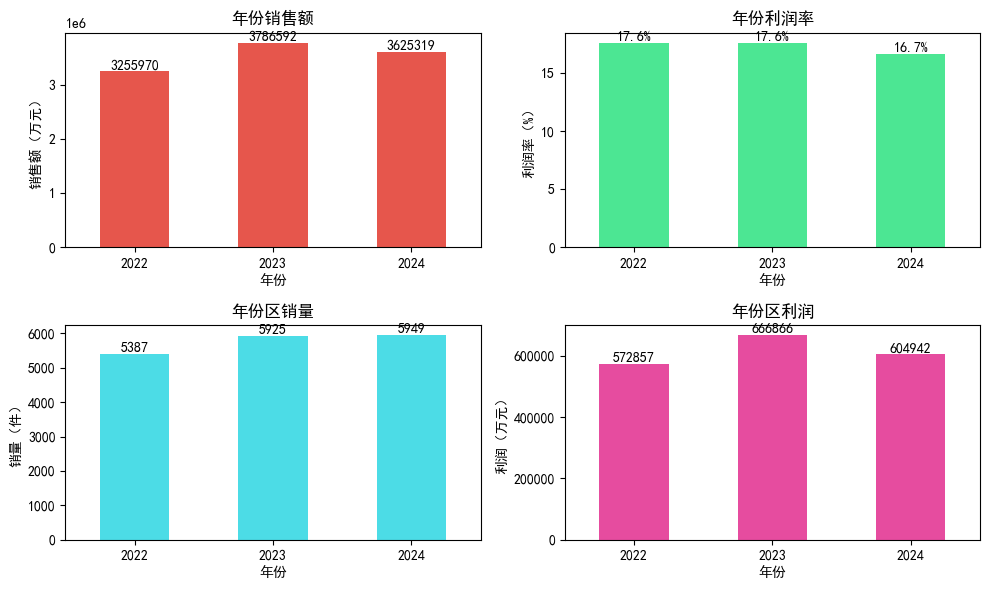

In [26]:
def bar_chart_yearly(ax,y_col,color,ylabel,title,data=yearly_stats,x_col='yearly',xlabel='年份',width=0.5,label_fmt='%.0f',label_padding=0,x_rotation=45,**label_kwargs):
    # label_padding=5 数值标签与柱子顶端之间的间距（像素），默认为0，贴紧bar
    sns.barplot(data=data,x=x_col,y=y_col,ax=ax,color=color,width=width,**label_kwargs)
    for cont in ax.containers:
        ax.bar_label(cont,fmt=label_fmt,padding=label_padding,**label_kwargs)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(xlabel)
        # ax.tick_params(axis='x',rotation=x_rotation)
    return ax


fig,ax=plt.subplots(2,2,figsize=(10,6))
bar_chart_yearly(ax[0][0],y_col='销售额',color=palettes[0],ylabel='销售额（万元）',title='年份销售额')
bar_chart_yearly(ax[0][1],y_col='margin',color=palettes[4],label_fmt='%.1f%%',ylabel='利润率（%）',title='年份利润率')
bar_chart_yearly(ax[1][0],y_col='数量',color=palettes[5],ylabel='销量（件）',title='年份区销量')
bar_chart_yearly(ax[1][1],y_col='利润',color=palettes[-1],ylabel='利润（万元）',title='年份区利润')

plt.tight_layout()
plt.show()

### 高价订单识别

In [27]:
high_sales=df.nlargest(10,'销售额')[['订单日期','产品名称','地区','销售额','利润']]
high_profit=df.nlargest(10,'利润')[['订单日期','产品名称','地区','销售额','利润']]

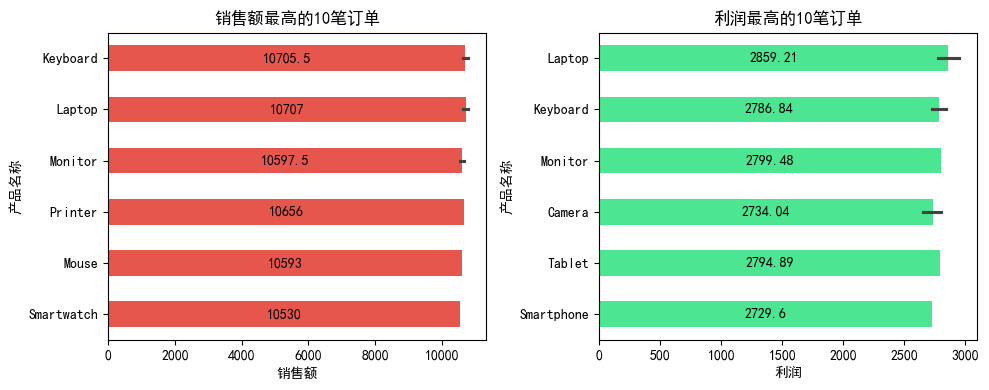

In [28]:
fig,ax=plt.subplots(1,2,figsize=(10,4))

sns.barplot(data=high_sales,x='销售额',y='产品名称',ax=ax[0],color=palettes[0],width=0.5)
ax[0].set_title('销售额最高的10笔订单')
sns.barplot(data=high_profit,x='利润',y='产品名称',ax=ax[1],color=palettes[4],width=0.5)
ax[1].set_title('利润最高的10笔订单')
for a in ax:
    for cont in a.containers:
        a.bar_label(cont,label_type='center')

plt.tight_layout()
plt.show()

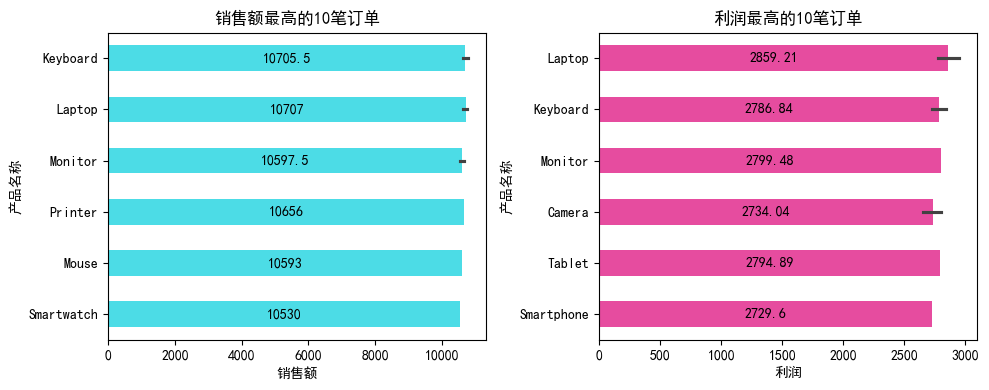

In [29]:
def high_order(ax,data,xcol,color,title,ycol='产品名称',width=0.5):
    sns.barplot(ax=ax,data=data,x=xcol,y=ycol,color=color,width=width)
    for cont in ax.containers:
        ax.bar_label(cont,label_type='center')
    ax.set_title(title)
    return ax

fig,ax=plt.subplots(1,2,figsize=(10,4))
high_order(ax[0],high_sales,'销售额',palettes[5],'销售额最高的10笔订单')
high_order(ax[1],high_profit,'利润',palettes[-1],'利润最高的10笔订单')

plt.tight_layout()
plt.show()

### 利润率分布

In [30]:
# 每单利润率
df['margin_anyone']=df['利润']/df['销售额']*100
df[df['margin_anyone']<0]

,订单日期,产品名称,类别,地区,数量,销售额,利润,yearmonthly,yearly,margin_anyone


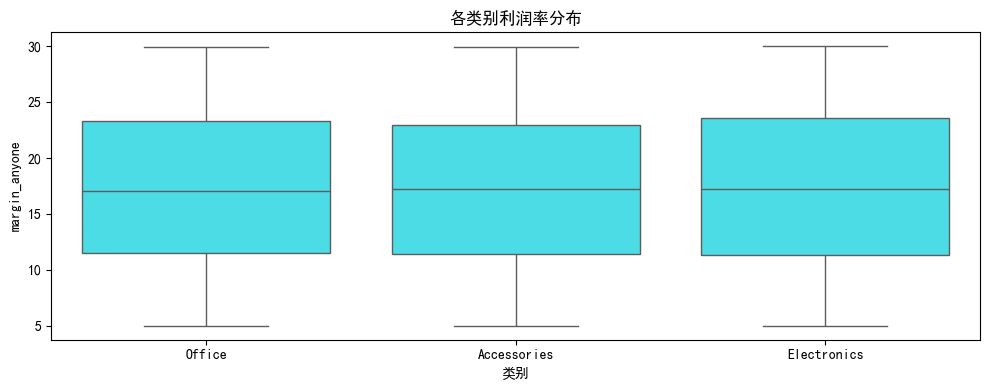

In [36]:
fig,ax=plt.subplots(figsize=(10,4))
sns.boxplot(data=df,x='类别',y='margin_anyone',ax=ax,color=palettes[5])
ax.set_title('各类别利润率分布')

plt.tight_layout()
plt.show()

### 销量与利润的关系

In [33]:
product_corr=df.groupby(by='产品名称').agg({
    '销售额':'sum',
    '利润':'sum',
    '数量':'sum'
}).reset_index()
product_corr['avgsale']=(product_corr['销售额']/product_corr['数量'])*100

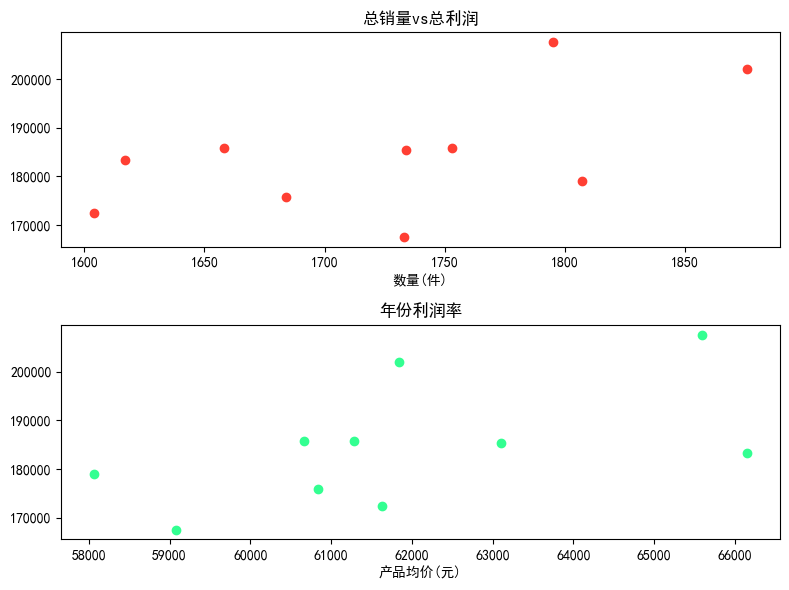

In [34]:
def scat_pro_quan(ax,x,color,xlabel,title,y=product_corr['利润']):
    # label_padding=5 数值标签与柱子顶端之间的间距（像素），默认为0，贴紧bar
    ax.scatter(x=x,y=y,color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
        # ax.tick_params(axis='x',rotation=x_rotation)
    return ax

fig,ax=plt.subplots(2,1,figsize=(8,6))
# 销量vs利润
scat_pro_quan(ax[0],product_corr['数量'],color=palettes[0],xlabel='数量(件)',title='总销量vs总利润')
# 平均售价vs利润
scat_pro_quan(ax[1],product_corr['avgsale'],color=palettes[4],xlabel='产品均价(元)',title='年份利润率')

plt.tight_layout()
plt.show()

### 区域 x 类别交叉分析

In [37]:
reg_cate=pd.pivot_table(
    df,
    values='销售额',
    index='地区',
    columns='类别',
    aggfunc='sum',
    fill_value=0
)
reg_cate

类别,Accessories,Electronics,Office
地区,,,
East,1032315,1377211,265584
North,1020641,1244702,223430
South,1076668,1245527,337353
West,1117967,1458634,267849


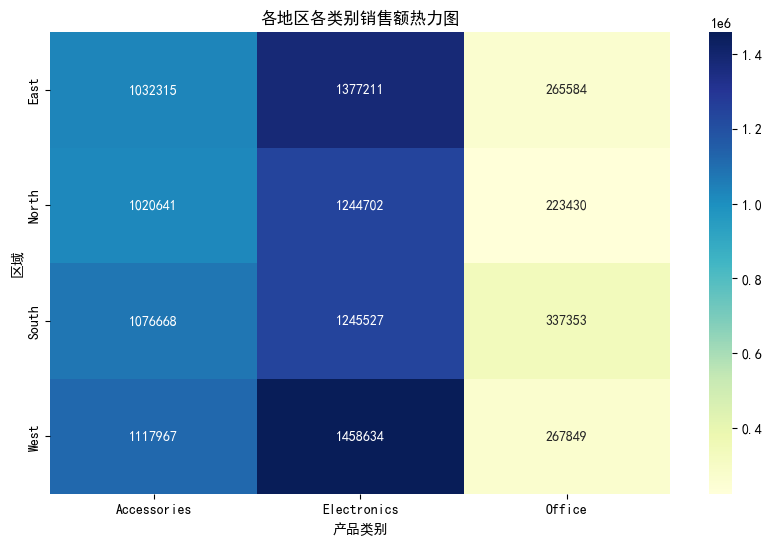

In [41]:
plt.figure(figsize=(10,6))
# sns.heatmap(reg_cate,annot=True,fmt='.0f',cmap='Blues_r',linewidths=0.5)
sns.heatmap(reg_cate,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('各地区各类别销售额热力图')
plt.ylabel('区域')
plt.xlabel('产品类别')
plt.show()


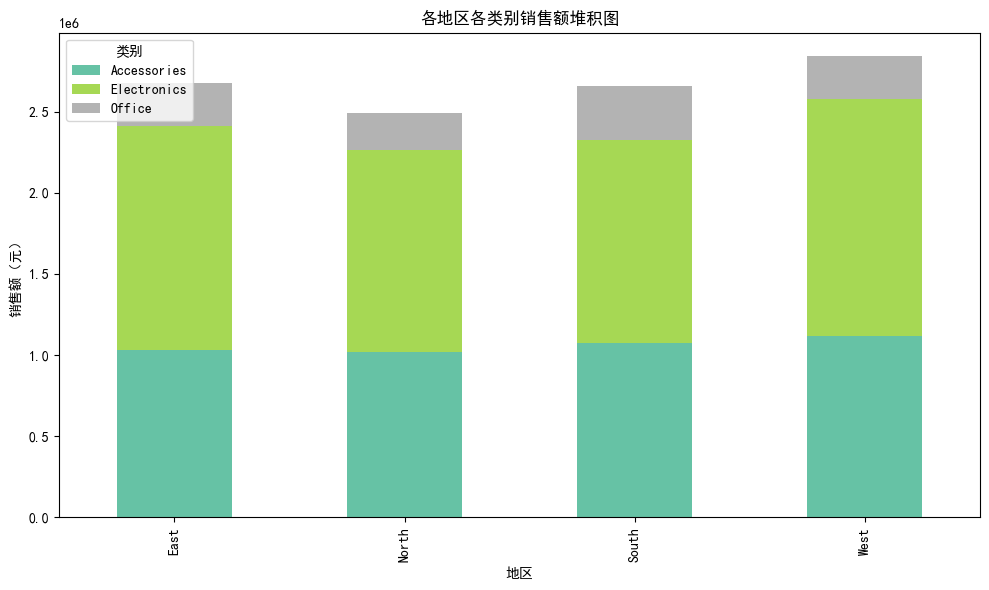

In [45]:
reg_cate.plot(kind='bar',stacked=True,figsize=(10,6),colormap='Set2')
plt.title('各地区各类别销售额堆积图')
plt.ylabel('销售额（元）')
plt.legend(title='类别')
plt.tight_layout()
plt.show()

### 月度销售波动与异常检测

In [46]:
df

,订单日期,产品名称,类别,地区,数量,销售额,利润,yearmonthly,yearly,margin_anyone
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024-12,2024,9.585989
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022-11,2022,8.899749
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022-05,2022,8.571697
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024-03,2024,25.810433
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022-09,2022,20.290766
...,...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16,2023-02,2023,18.975394
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89,2022-09,2022,10.733214
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02,2022-04,2022,25.392308
3498,2022-01-18,Printer,Office,South,3,222,50.28,2022-01,2022,22.648649


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   订单日期            3500 non-null   datetime64[ns]
 1   产品名称            3500 non-null   object        
 2   类别              3500 non-null   object        
 3   地区              3500 non-null   object        
 4   数量              3500 non-null   int64         
 5   销售额             3500 non-null   int64         
 6   利润              3500 non-null   float64       
 7   yearmonthly     3500 non-null   object        
 8   yearly          3500 non-null   object        
 9   margin_anyone   3500 non-null   float64       
 10  monthy_salepre  3464 non-null   float64       
 11  mm_growth       3464 non-null   float64       
 12  anomaly         3500 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 355.6+ KB


In [124]:
monthly_sales=df.groupby(by='yearmonthly')['销售额'].sum().reset_index()
mon_sale=monthly_sales['销售额']
mon_ym=monthly_sales['yearmonthly']
monthly_sale_prev=mon_sale.shift(1)
monthly_sale_prev

mm_growth=(mon_sale-monthly_sale_prev)/monthly_sale_prev*100
mm_growth

# anomaly = np.where(abs(mm_growth) > 50, '异常', '正常')
# 异常波动点
anomaly_points=monthly_sales[abs(mm_growth)>50]
anomaly_points

,yearmonthly,销售额
26,2024-03,341563


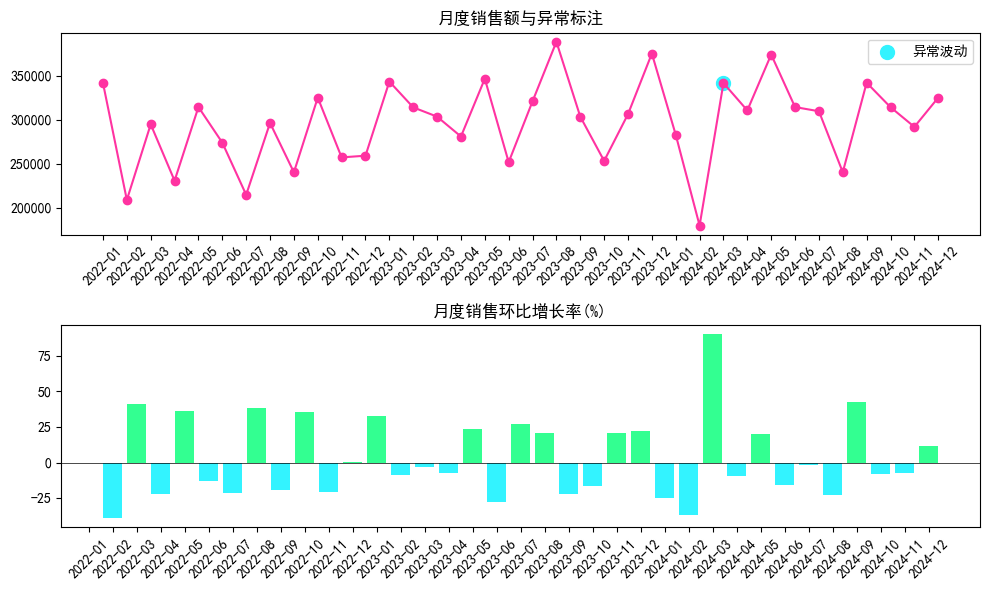

In [121]:
fig,ax=plt.subplots(2,1,figsize=(10,6))

# 月度销售额+异常标注
ax[0].plot(mon_ym,mon_sale,marker='o',color=palettes[-1])
ax[0].scatter(anomaly_points['yearmonthly'],anomaly_points['销售额'],color=palettes[5],s=100,label='异常波动')
ax[0].set_title('月度销售额与异常标注')
ax[0].tick_params(axis='x',rotation=45)
ax[0].legend()

# 环比增长率
colors=[palettes[5] if x <0 else palettes[4] for x in mm_growth]
ax[1].bar(mon_ym,mm_growth,color=colors)
ax[1].axhline(y=0,color='black',linestyle='-',linewidth=0.5)
ax[1].set_title('月度销售环比增长率(%)')
ax[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

# 总结

- 一、核心数据概览
    - 总销售额 1,066.8 万元，总利润 184.5 万元，平均利润率 17.29%，覆盖 2022-2024 三年共 3,500 笔订单，所有订单全部盈利，无缺失、无重复数据，整体经营健康。
- 二、关键发现与针对性建议
    - 产品策略优化
        - 发现：Camera、Monitor、Printer 三大产品贡献最高销售额和利润；单笔高价值订单集中在 Keyboard、Laptop 品类
        - 建议：
            - 明星产品强化：对 Camera、Monitor 加大市场投入，作为核心引流产品，可推出组合套餐提升客单价
            - 高价值产品深耕：Keyboard、Laptop 单笔利润最高，建议针对性开发高端系列，提升溢价空间
            - 长尾产品激活：对销量偏低产品进行 SKU 优化，考虑捆绑销售或促销清库存
    - 品类结构调整
        - 发现：Electronics 贡献 50% 销售额，Accessories 利润率最高 17.3%，Office 品类表现最弱
        - 建议：
            - 资源倾斜：将 70% 营销预算投向 Electronics 和 Accessories 两大高价值品类
            - Office 品类重塑：Office 品类销售额仅 109 万，建议精简 SKU 保留高利润单品，与 Electronics 产品做捆绑销售（如买电脑送打印机耗材），考虑外包或联营模式降低运营成本
            - 配件品类提量：Accessories 利润率最高但销量有提升空间，可做 "满额赠配件" 活动拉动销量
    - 区域市场布局
        - 发现：西部地区全面领先，销售额 284.4 万、利润 49.5 万，均居首位；北部地区相对较弱
        - 建议：
            - 西部市场深耕：西部地区 Electronics 表现尤为突出，可设立区域运营中心，扩大本地仓储提升配送效率
            - 北部市场突破：北部销售额最低 248.9 万，建议开展区域专属促销活动，调研本地竞品定价调整价格策略，加强本地渠道合作
            - 区域差异化策略：东部 / 南部侧重 Accessories，西部 / 北部侧重 Electronics 品类推广
    - 时间节奏把控
        - 发现：2023 年业绩峰值，2024 年略有回落；利润率逐年微降，从 17.6% 降至 16.7%；2024 年 3 月出现异常波动
        - 建议：
            - 利润率管控：针对利润率下滑趋势，开展供应链成本谈判降低采购成本，优化定价策略避免过度低价竞争，定期复盘高折扣订单评估投入产出
            - 季节性营销：分析月度波动规律，在销售淡季如年初提前布局促销活动
            - 异常波动复盘：深入分析 2024 年 3 月增长原因，复制成功经验到其他月份
    - 客户价值提升
        - 发现：销量、均价与利润呈显著正相关
        - 建议：
            - 客单价提升：推行 "满减阶梯"、"第二件折扣" 等策略，鼓励客户多买
            - 高端客户运营：针对高价值订单客户建立 VIP 体系，提供专属服务和复购优惠
            - 交叉销售：基于购买记录做关联推荐，如买 Monitor 推荐 Keyboard
- 三、优先级行动清单
    - 高优先级：
        - Office 品类 SKU 精简与捆绑策略，预期提升该品类利润率 5% 以上
        - 北部市场专项促销活动，预期缩小区域差距，提升销售额 10%
    - 中优先级：
        - Camera/Monitor 组合套餐推广，预期客单价提升 15%
        - 供应链成本谈判，预期整体利润率提升 0.5-1 个百分点
    -持续跟进：
        - 月度销售异常监控与复盘，及时发现问题、复制成功
- 四、整体评估
    - 经营健康度：优秀
    - 优势：全订单盈利、现金流健康、核心产品明确、区域有增长极
    - 改进点：品类发展不均衡、区域差异较大、利润率呈下滑趋势、Office 品类拖后腿
    - 核心结论：公司整体经营状况良好，建议聚焦 "做强核心品类、突破弱势区域、管控利润率下滑" 三大方向，预计可实现下一年度业绩 15%-20% 增长。